# Titanic Survival Prediction using Machine Learning

## Objective

Build a classification model that predicts passenger survival using historical Titanic passenger data.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Dataset

Titanic Dataset

## Workflow

1. Import Libraries
2. Load Dataset
3. Data Inspection
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Data Preprocessing
8. Train-Test Split
9. Logistic Regression Model
10. Model Evaluation
11. Business Insights

# Import Required Libraries

In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


# Load Dataset

In [64]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


# Data Inspection

In [65]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [66]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [68]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [69]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Data Cleaning

In this step, we handle missing values, remove unnecessary columns, and prepare the dataset for machine learning.

In [70]:
# Missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Fill Missing Embarked

In [71]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

Drop Cabin

In [72]:
df.drop('Cabin', axis=1, inplace=True)

In [73]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

# Exploratory Data Analysis

Survival Count

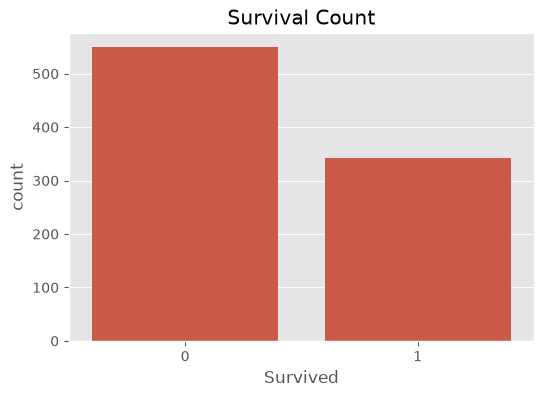

In [74]:
plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df)

plt.title("Survival Count")

plt.show()

Survival by Gender

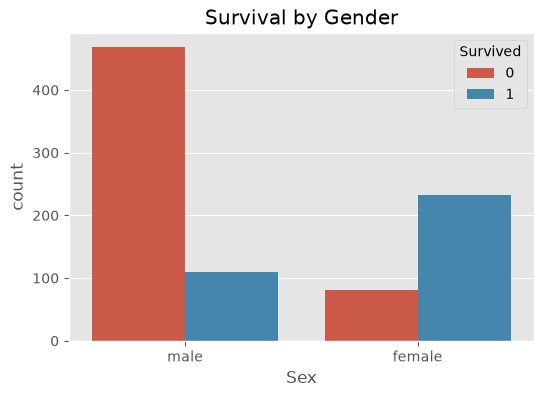

In [75]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', hue='Survived', data=df)

plt.title("Survival by Gender")

plt.show()

Passenger Class Distribution

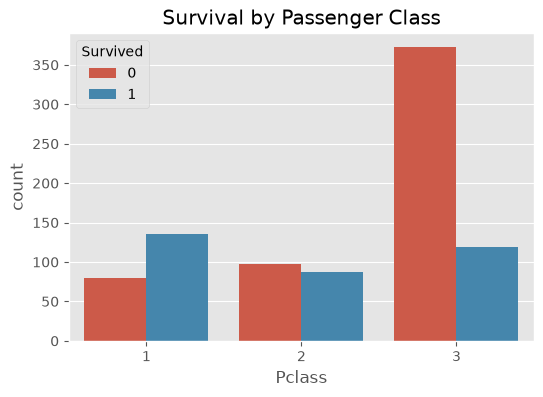

In [76]:
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Survival by Passenger Class")

plt.show()

Age Distribution

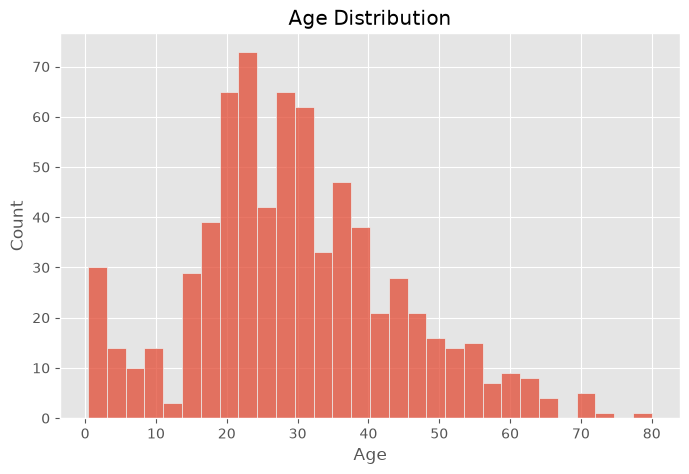

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30)

plt.title("Age Distribution")

plt.show()

Fare Distribution

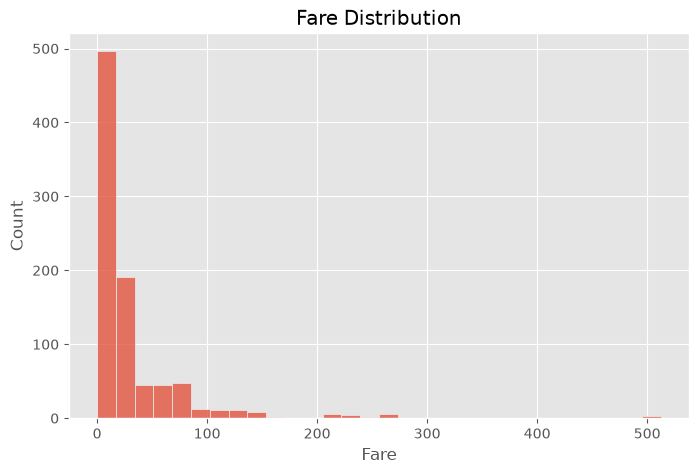

In [78]:
plt.figure(figsize=(8,5))

sns.histplot(df['Fare'], bins=30)

plt.title("Fare Distribution")

plt.show()

# Feature Engineering

In [79]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [80]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Data Preprocessing

In [81]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])

df['Embarked'] = encoder.fit_transform(df['Embarked'])

In [82]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


Train/Test Split

In [83]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)

y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (712, 7)
Testing Data: (179, 7)


Logistic Regression Model

In [84]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
X.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64

In [ ]:
X['Age'] = X['Age'].fillna(X['Age'].median())

In [ ]:
X.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Train Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
X_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Embarked      0
dtype: int64

In [ ]:
X['Age'] = X['Age'].fillna(X['Age'].median())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


Make Predictions

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


Accuracy Score

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 81.01 %


Confusion Matrix

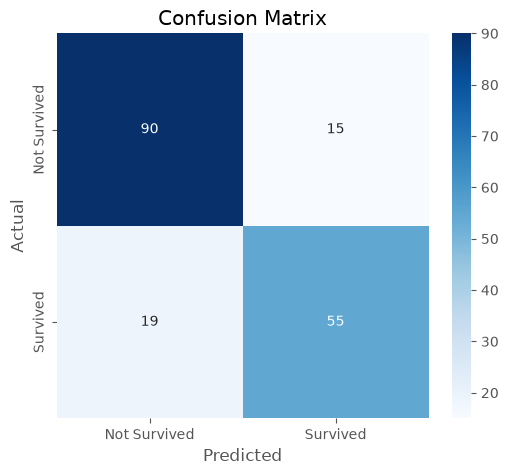

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Survived','Survived'],
    yticklabels=['Not Survived','Survived']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("Output/confusion_matrix.png")

plt.show()

Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



Feature Importance

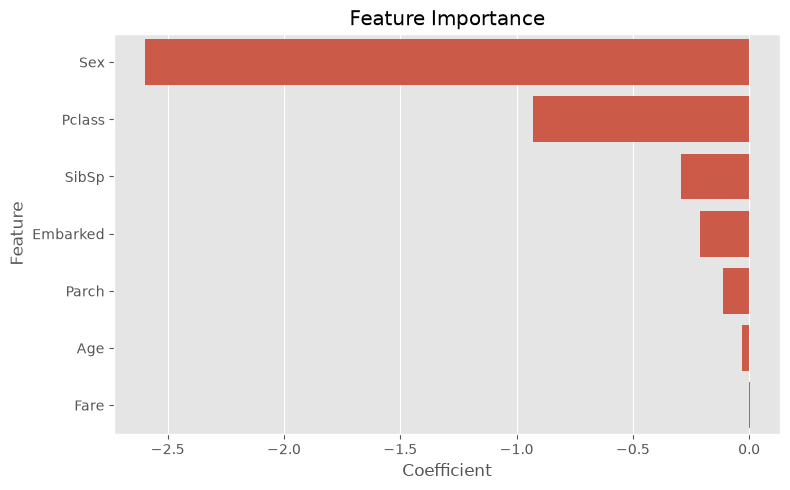

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient")

plt.figure(figsize=(8,5))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.tight_layout()

plt.savefig("Output/feature_importance.png")

plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

importance

,Feature,Coefficient
1,Sex,-2.598673
0,Pclass,-0.931417
3,SibSp,-0.294679
6,Embarked,-0.212699
4,Parch,-0.112680
2,Age,-0.030404
5,Fare,0.002563


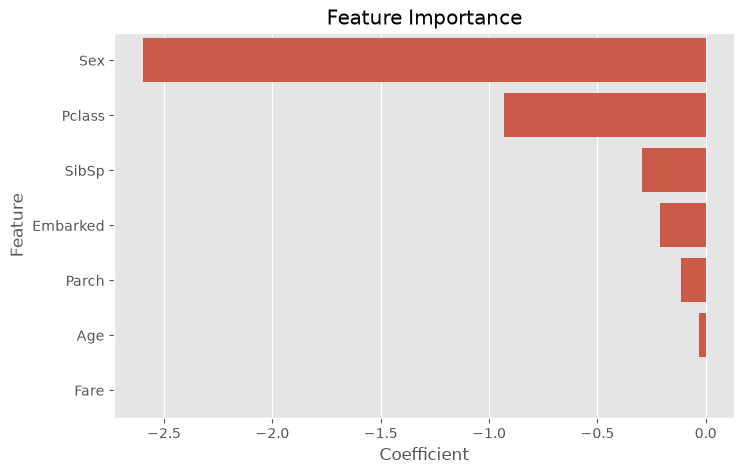

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance")

plt.savefig("Output/feature_importance.png")

plt.show()

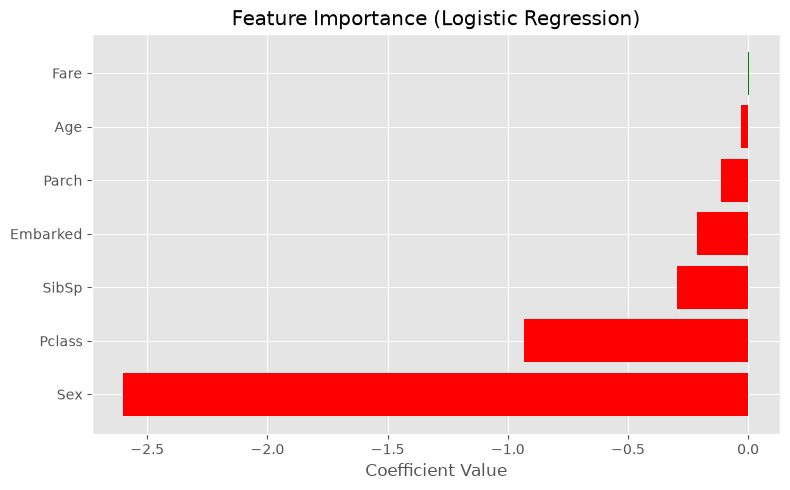

In [ ]:
colors = ["green" if x > 0 else "red" for x in importance["Coefficient"]]

plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Coefficient"],
    color=colors
)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.tight_layout()

plt.savefig("Output/feature_importance.png")
plt.show()

### Key Findings

• Female passengers had a higher survival probability.

• First Class passengers survived more often than Third Class.

• Younger passengers had a slightly higher chance of survival.

• Higher Fare passengers generally survived more.

• Embarked location had a small influence.

• Family size affected survival probability.

### Business Recommendation

The model predicts passenger survival with approximately 81% accuracy.

Passenger demographics and travel class strongly influence survival.

Such classification models can help organizations identify high-risk groups and improve emergency planning.